In [ ]:
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Notebook settings
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 120)
plt.rcParams.update({'figure.max_open_warning': 0})
random_state = 42

In [ ]:
import pandas as pd

df_raw = pd.read_excel(r"C:\Users\4951426\OneDrive - Lowe's Companies Inc\Downloads\Credit Card Customer Data.xlsx")

In [ ]:
df.head()


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [ ]:
# Robust matching of columns to expected fields
expected_keywords = {
    'Average Credit Limit': ['avg','credit','limit'],
    'Total credit cards': ['total','credit','card'],
    'Total visits bank': ['visit','bank'],
    'Total visits online': ['visit','online'],
    'Total calls made': ['call']
}

In [ ]:
# Build normalized tokens for matching
col_norm = {orig: re.sub(r'[^0-9a-zA-Z]+', '_', orig.strip()).lower() for orig in df_raw.columns}

def find_col_by_keywords(keywords):
    for orig, norm in col_norm.items():
        if all(k in norm for k in keywords):
            return orig
    return None

matched = {}
for friendly, kws in expected_keywords.items():
    col = find_col_by_keywords(kws)
    matched[friendly] = col

print("Auto-matched columns (friendly name -> detected original name):")
for k, v in matched.items():
    print(f" - {k} -> {v}")

# If any required column is not found raise an informative error
missing = [k for k, v in matched.items() if v is None]
if missing:
    raise ValueError(f"Could not auto-match required columns for: {missing}. "
                     "Please verify Excel column names and retry or update expected_keywords.")

# Create working dataframe with standardized column names
df = df_raw.rename(columns={v: k for k, v in matched.items()})
features = list(matched.keys())  # standardized feature names
print("\nStandardized features used:", features)



Auto-matched columns (friendly name -> detected original name):
 - Average Credit Limit -> Avg_Credit_Limit
 - Total credit cards -> Total_Credit_Cards
 - Total visits bank -> Total_visits_bank
 - Total visits online -> Total_visits_online
 - Total calls made -> Total_calls_made

Standardized features used: ['Average Credit Limit', 'Total credit cards', 'Total visits bank', 'Total visits online', 'Total calls made']


EDA

In [ ]:
# Convert features to numeric and fill missing values with median
for f in features:
    df[f] = pd.to_numeric(df[f], errors='coerce')
    na = df[f].isna().sum()
    if na > 0:
        med = df[f].median()
        df[f].fillna(med, inplace=True)
        print(f"Filled {na} missing in '{f}' with median {med}")


In [ ]:
# Show descriptive stats
print("\nDescriptive statistics:")
display(df[features].describe().T)



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Average Credit Limit,660.0,34574.242424,37625.487804,3000.0,10000.0,18000.0,48000.0,200000.0
Total credit cards,660.0,4.706061,2.167835,1.0,3.0,5.0,6.0,10.0
Total visits bank,660.0,2.403030,1.631813,0.0,1.0,2.0,4.0,5.0
Total visits online,660.0,2.606061,2.935724,0.0,1.0,2.0,4.0,15.0
Total calls made,660.0,3.583333,2.865317,0.0,1.0,3.0,5.0,10.0


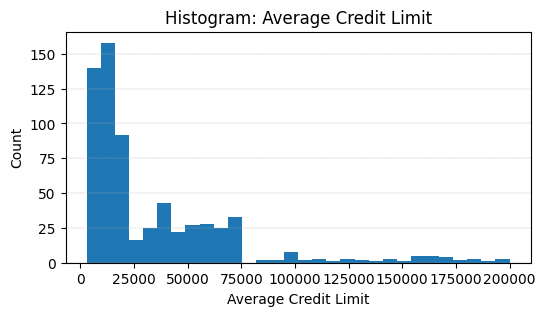

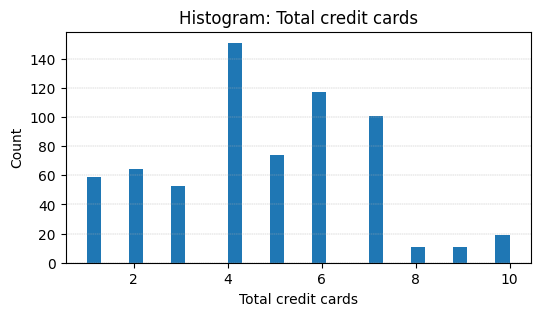

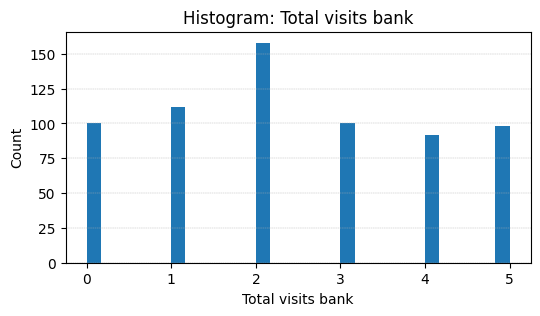

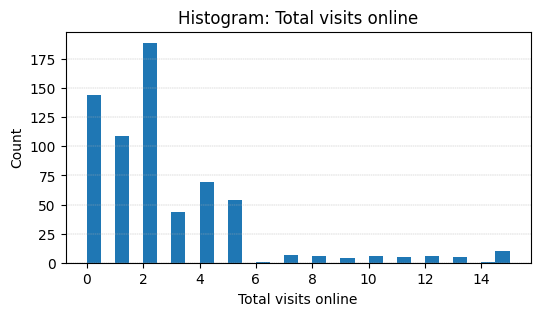

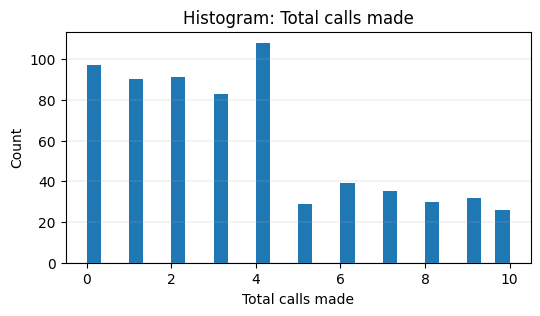

In [ ]:
# Histograms to visualize distributions
for f in features:
    plt.figure(figsize=(6,3))
    plt.hist(df[f].dropna(), bins=30)
    plt.title(f"Histogram: {f}")
    plt.xlabel(f)
    plt.ylabel("Count")
    plt.grid(axis='y', linestyle='--', linewidth=0.3)
    plt.show()

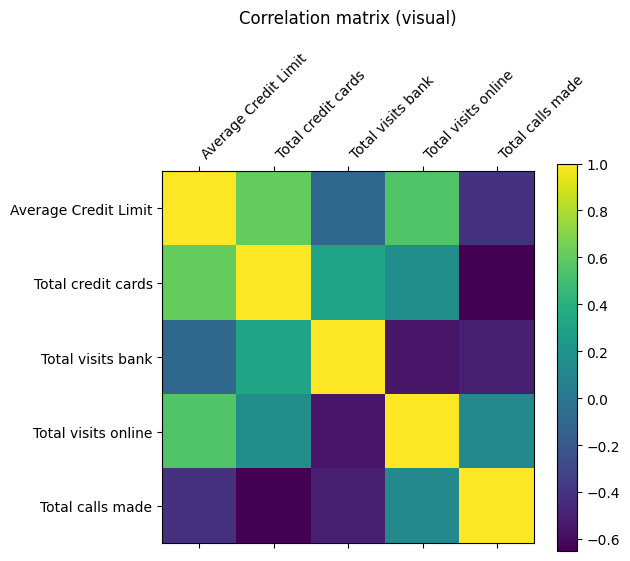


Correlation matrix values:


,Average Credit Limit,Total credit cards,Total visits bank,Total visits online,Total calls made
Average Credit Limit,1.000000,0.608860,-0.100312,0.551385,-0.414352
Total credit cards,0.608860,1.000000,0.315796,0.167758,-0.651251
Total visits bank,-0.100312,0.315796,1.000000,-0.551861,-0.506016
Total visits online,0.551385,0.167758,-0.551861,1.000000,0.127299
Total calls made,-0.414352,-0.651251,-0.506016,0.127299,1.000000


In [ ]:
# Correlation matrix (visual + numeric)
corr = df[features].corr()
plt.figure(figsize=(6,5))
plt.matshow(corr, fignum=1)
plt.xticks(range(len(features)), features, rotation=45, ha='left')
plt.yticks(range(len(features)), features)
plt.colorbar()
plt.title("Correlation matrix (visual)", pad=20)
plt.show()
print("\nCorrelation matrix values:")
display(corr)

Transform skewed features & scaling

In [ ]:
# Use Yeo-Johnson to reduce skewness (works with zeros/negative)
pt = PowerTransformer(method='yeo-johnson')
X_raw = df[features].values
X_trans = pt.fit_transform(X_raw)


In [ ]:
# Attach transformed features to dataframe for traceability
trans_features = [f + "_trans" for f in features]
for i, f in enumerate(features):
    df[trans_features[i]] = X_trans[:, i]


In [ ]:
# Standard scale transformed features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[trans_features])

print("Transformed feature names:", trans_features)
print("X_scaled shape:", X_scaled.shape)
print("Scaled means (approx):", np.round(X_scaled.mean(axis=0), 5))
print("Scaled stds (approx):", np.round(X_scaled.std(axis=0), 5))

Transformed feature names: ['Average Credit Limit_trans', 'Total credit cards_trans', 'Total visits bank_trans', 'Total visits online_trans', 'Total calls made_trans']
X_scaled shape: (660, 5)
Scaled means (approx): [0. 0. 0. 0. 0.]
Scaled stds (approx): [1. 1. 1. 1. 1.]


Choose optimal k using Elbow & Silhouette

In [ ]:
# Select a reasonable range of k
n = X_scaled.shape[0]
max_k = min(8, max(4, n//40 + 3))
K_range = list(range(2, max_k+1))
print("Testing k values:", K_range)

inertia = []
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
    labs = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labs))
    print(f"k={k} -> inertia={km.inertia_:.2f}, silhouette={sil_scores[-1]:.4f}")

Testing k values: [2, 3, 4, 5, 6, 7, 8]
k=2 -> inertia=1900.82, silhouette=0.4034
k=3 -> inertia=1275.58, silhouette=0.4625
k=4 -> inertia=1039.28, silhouette=0.3666
k=5 -> inertia=932.68, silhouette=0.3486
k=6 -> inertia=855.46, silhouette=0.3394
k=7 -> inertia=791.25, silhouette=0.2472
k=8 -> inertia=732.64, silhouette=0.2485


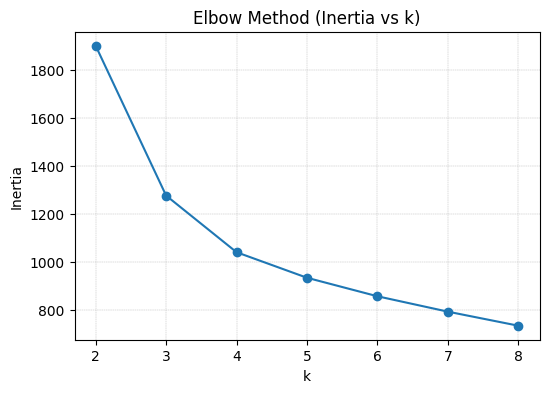

In [ ]:
# Plot elbow
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, '-o')
plt.title('Elbow Method (Inertia vs k)')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.grid(True, linestyle='--', linewidth=0.3)
plt.show()

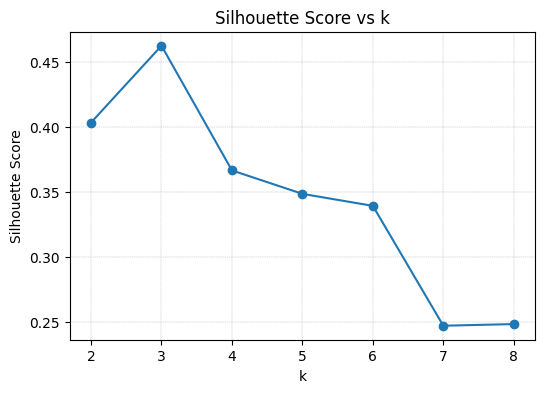

In [ ]:
# Plot silhouette
plt.figure(figsize=(6,4))
plt.plot(K_range, sil_scores, '-o')
plt.title('Silhouette Score vs k')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--', linewidth=0.3)
plt.show()

In [ ]:
# Choose best k by max silhouette score
best_k = K_range[int(np.argmax(sil_scores))]
print("Selected best_k (max silhouette):", best_k)

Selected best_k (max silhouette): 3


Fit KMeans & attach clusters

In [ ]:
# Fit final KMeans
kmeans = KMeans(n_clusters=best_k, random_state=random_state, n_init=30)
labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = labels.astype(int)


In [ ]:
# Compute cluster centers in original (pre-transform) space for interpretability
centers_scaled = kmeans.cluster_centers_                 # in scaled(transformed) space
centers_trans = scaler.inverse_transform(centers_scaled) # back to transformed space
# inverse power transform back to original units (wrap in try-except)
try:
    centers_orig = pt.inverse_transform(centers_trans)
except Exception:
    centers_orig = centers_trans  # fallback if inverse fails numerically

centers_df = pd.DataFrame(centers_orig, columns=features)
centers_df.index.name = 'Cluster'
print("Cluster centers (original feature scale):")
display(centers_df.round(2))

Cluster centers (original feature scale):


,Average Credit Limit,Total credit cards,Total visits bank,Total visits online,Total calls made
Cluster,,,,,
0,24082.59,5.50,3.45,0.75,1.71
1,132768.04,8.69,0.58,10.27,0.99
2,10842.09,2.39,0.89,3.35,6.63


In [ ]:
# Attach PCA coordinates for plotting / optional export
pca = PCA(n_components=2, random_state=random_state)
coords = pca.fit_transform(X_scaled)
df['PCA1'] = coords[:,0]; df['PCA2'] = coords[:,1]

Hierarchical diagnostic dendrogram

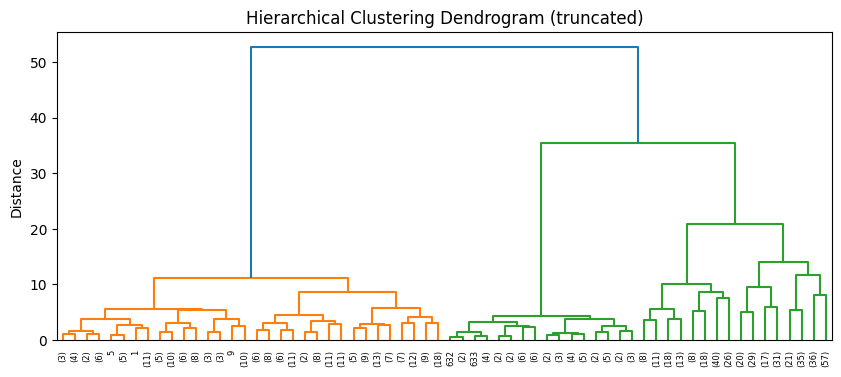

In [ ]:
# Hierarchical dendrogram to get an alternative view
try:
    Z = linkage(X_scaled, method='ward')
    plt.figure(figsize=(10,4))
    dendrogram(Z, truncate_mode='level', p=5, show_leaf_counts=True)
    plt.title('Hierarchical Clustering Dendrogram (truncated)')
    plt.ylabel('Distance')
    plt.show()
except Exception as e:
    print("Dendrogram plotting failed:", e)

Cluster profiling & sizes

In [ ]:
# Cluster profiling: count, mean, median, std for each feature
profile = df.groupby('Cluster')[features].agg(['count','mean','median','std']).round(2)
print("Cluster profiling (count, mean, median, std):")
display(profile)

cluster_counts = df['Cluster'].value_counts().sort_index()
cluster_pct = (cluster_counts / len(df) * 100).round(2)
print("Cluster sizes and percentages:")
display(pd.DataFrame({'count': cluster_counts, 'pct': cluster_pct}))

Cluster profiling (count, mean, median, std):


Average Credit Limit                                Total credit cards                    Total visits bank  \
                       count       mean    median       std              count  mean median   std             count   
Cluster                                                                                                               
0                        382   33950.26   31500.0  22142.11                382  5.52    6.0  1.14               382   
1                         51  139254.90  145000.0  36415.84                 51  8.71    9.0  1.29                51   
2                        227   12105.73   11000.0   5248.46                227  2.44    2.0  1.12               227   

                           Total visits online                     Total calls made                     
         mean median   std               count   mean median   std            count  mean median   std  
Cluster                                                                                                 
0        3.51    3.0  1.13                 382   0.97    1.0  0.85              382  1.98    2.0  1.43  
1        0.61    1.0  0.49                  51  10.75   11.0  3.06               51  1.14    1.0  0.96  
2        0.95    1.0  0.82                 227   3.53    4.0  1.22              227  6.82    7.0  2.02

Cluster sizes and percentages:


,count,pct
Cluster,,
0,382,57.88
1,51,7.73
2,227,34.39


Statistical tests across clusters — Kruskal-Wallis

In [ ]:
# Non-parametric test to check whether clusters differ for each feature
print("Kruskal-Wallis test results (H statistic, p-value):")
for f in features:
    groups = [df[df['Cluster']==c][f].values for c in sorted(df['Cluster'].unique())]
    if all(len(g) > 0 for g in groups):
        stat, p = stats.kruskal(*groups)
        print(f" - {f}: H = {stat:.3f}, p = {p:.4e}")
    else:
        print(f" - {f}: insufficient group sizes for test")

Kruskal-Wallis test results (H statistic, p-value):
 - Average Credit Limit: H = 265.102, p = 2.7154e-58
 - Total credit cards: H = 460.641, p = 9.3997e-101
 - Total visits bank: H = 437.787, p = 8.6235e-96
 - Total visits online: H = 452.224, p = 6.3200e-99
 - Total calls made: H = 425.489, p = 4.0396e-93


Cluster centers heatmap & PCA scatter

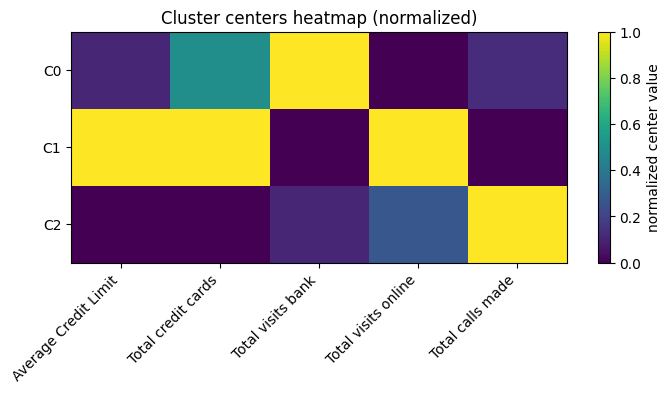

In [ ]:
# Heatmap of cluster centers (normalized for visual comparison)
center_rel = centers_df.copy()
center_rel = (center_rel - center_rel.min()) / (center_rel.max() - center_rel.min())
plt.figure(figsize=(8, 1.2 + 0.6*len(center_rel)))
plt.imshow(center_rel.values, aspect='auto')
plt.colorbar(label='normalized center value')
plt.yticks(range(len(center_rel)), [f"C{c}" for c in center_rel.index])
plt.xticks(range(len(center_rel.columns)), center_rel.columns, rotation=45, ha='right')
plt.title("Cluster centers heatmap (normalized)")
plt.show()

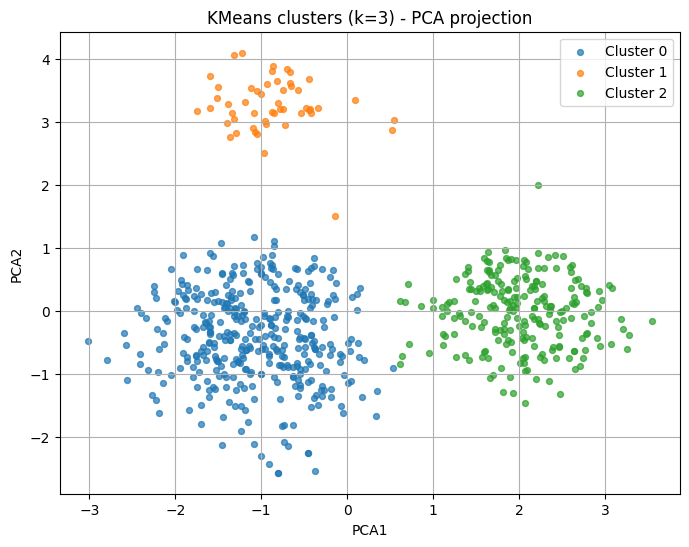

In [ ]:
# PCA scatter (colored by cluster)
plt.figure(figsize=(8,6))
for cl in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster']==cl]
    plt.scatter(sub['PCA1'], sub['PCA2'], s=18, alpha=0.7, label=f'Cluster {cl}')
plt.title(f"KMeans clusters (k={best_k}) - PCA projection")
plt.xlabel("PCA1"); plt.ylabel("PCA2"); plt.legend(); plt.grid(True); plt.show()